<a href="https://colab.research.google.com/github/alfey504/retail-promotions-performance-analyzer-backend/blob/main/diabetes_progression_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Progression Prediction

**Dataset:** `load_diabetes()` from scikit-learn

**Objective:** Predict disease progression based on patient health measurements.

## Step 1: Load the dataset

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

data = load_diabetes(as_frame=True)
df = data.frame
df.rename(columns={'target': 'disease_progression'}, inplace=True)
print(df.head())
print(df.shape)
print(df.info())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  disease_progression  
0 -0.002592  0.019907 -0.017646                151.0  
1 -0.039493 -0.068332 -0.092204                 75.0  
2 -0.002592  0.002861 -0.025930                141.0  
3  0.034309  0.022688 -0.009362                206.0  
4 -0.002592 -0.031988 -0.046641                135.0  
(442, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0  

## Step 2: Perform EDA

In [16]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [17]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


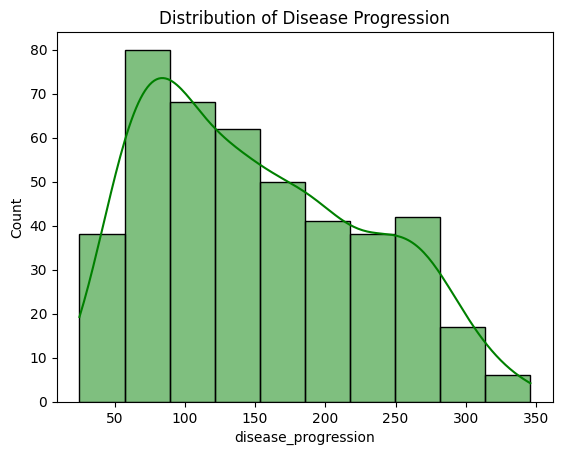

In [38]:
sns.histplot(df['disease_progression'], kde=True,color="green")
plt.title("Distribution of Disease Progression")
plt.show()

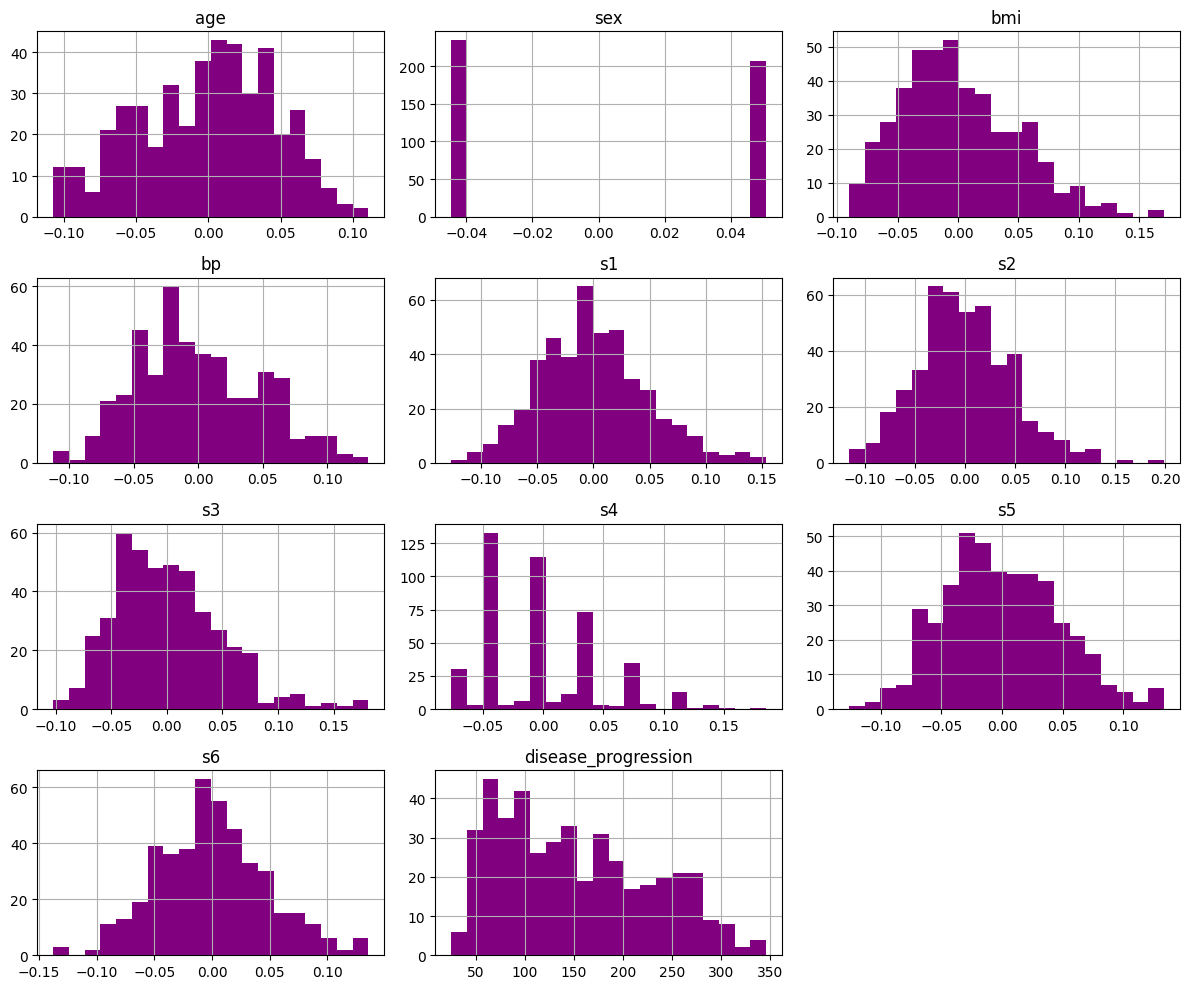

In [39]:
df.hist(figsize=(12, 10), bins=20,color="purple")
plt.tight_layout()
plt.show()

## Step 3: Check feature correlations

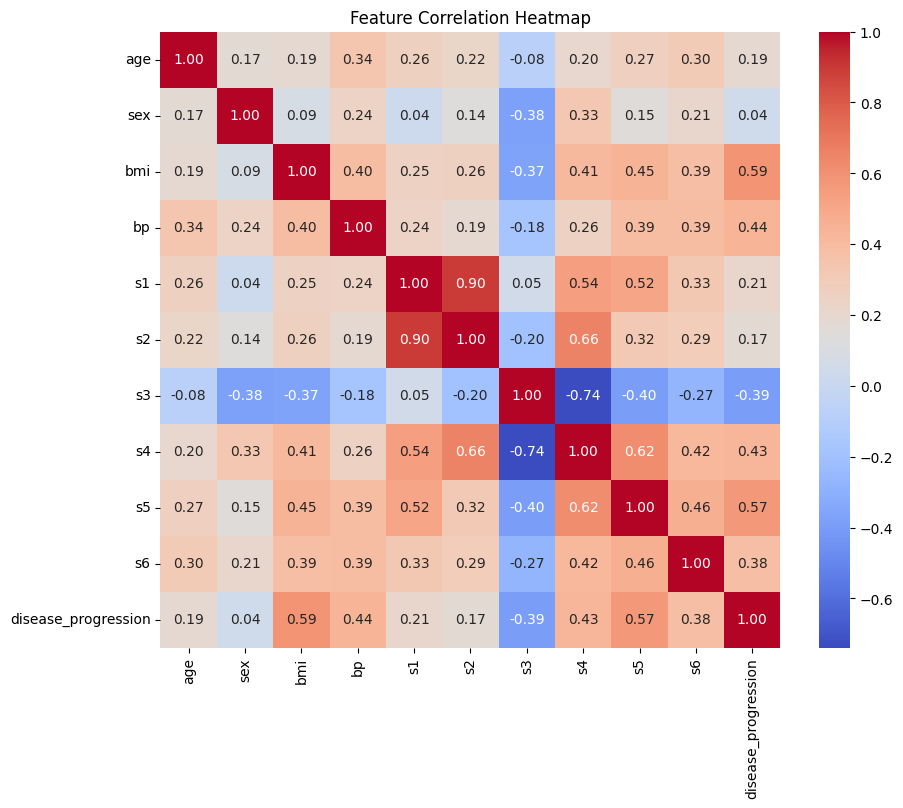

In [20]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [21]:
print(corr_matrix['disease_progression'].sort_values(ascending=False))

disease_progression    1.000000
bmi                    0.586450
s5                     0.565883
bp                     0.441482
s4                     0.430453
s6                     0.382483
s1                     0.212022
age                    0.187889
s2                     0.174054
sex                    0.043062
s3                    -0.394789
Name: disease_progression, dtype: float64


## Step 4: Train a Linear Regression model

In [22]:
X = df.drop('disease_progression', axis=1)
y = df['disease_progression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=67
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Step 5: Evaluate using R², MAE, RMSE

In [23]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.5580
MAE: 40.8884
RMSE: 47.2857


## Step 6: Identify the most influential features

In [24]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coeff_df)

  Feature  Coefficient
8      s5   640.130057
4      s1  -598.556637
2     bmi   550.340164
5      s2   337.389516
3      bp   319.100221
1     sex  -240.686856
7      s4   197.848085
9      s6    72.104367
0     age   -26.876136
6      s3    17.386862


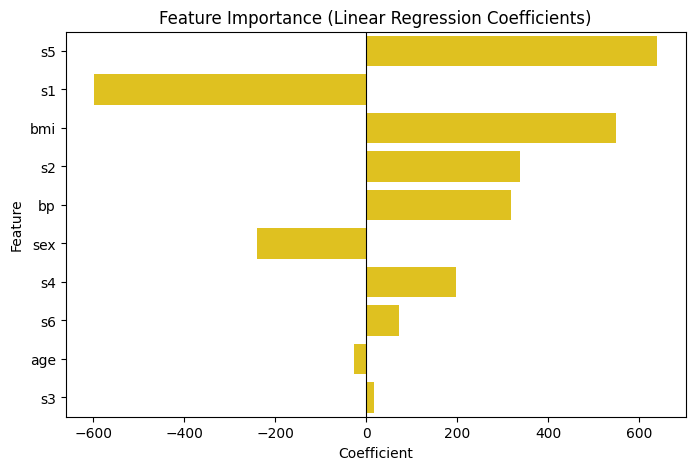

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=coeff_df, x='Coefficient', y='Feature',color="gold")
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

## Step 7: Compare actual vs predicted values

/tmp/ipykernel_863/231975728.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--',color="blue")


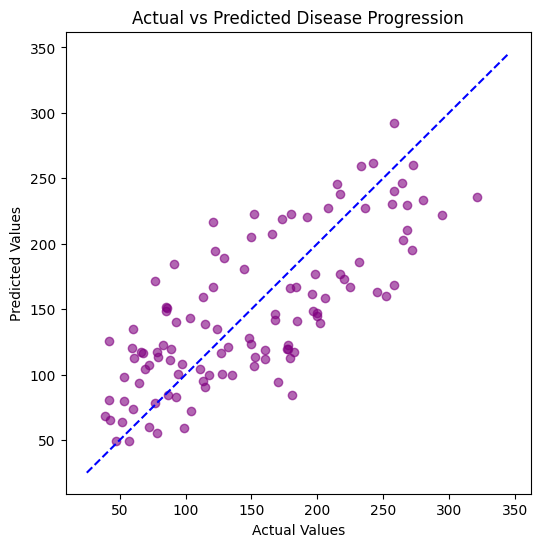

In [33]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6,color="purple")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--',color="blue")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Disease Progression")
plt.show()

In [27]:
comparison_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred}).reset_index(drop=True)
print(comparison_df.head(10))

   Actual   Predicted
0    85.0  151.599516
1   258.0  292.149145
2   129.0  188.894006
3   153.0  113.391269
4    94.0  100.737802
5   268.0  210.338943
6   273.0  260.553381
7   103.0  142.936287
8   180.0  222.473851
9   197.0  148.976028


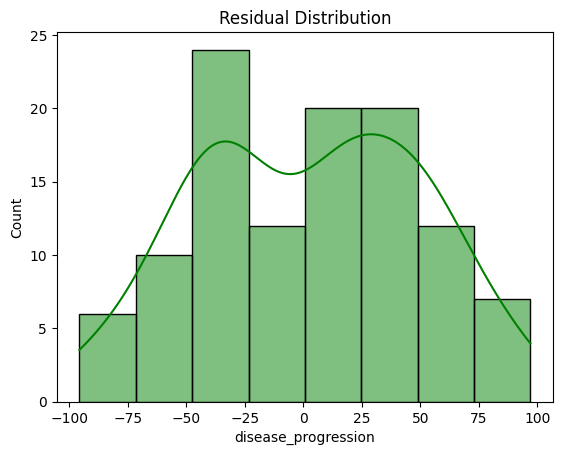

In [29]:
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='Green')
plt.title("Residual Distribution")
plt.show()